In [1]:
import pandas as pd

C:\Users\Salif\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [7]:
data=pd.read_csv('C:/Users/Salif/Downloads/dataset_heart.csv')

In [10]:
data.head()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

In [16]:
data.isna().sum()

age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64

Nous pouvons constaté qu'il n y a pas de valeurs manquantes. Donc pas de gros nettoyage à faire.

In [19]:
import seaborn as sns

<Axes: xlabel='heart disease', ylabel='count'>

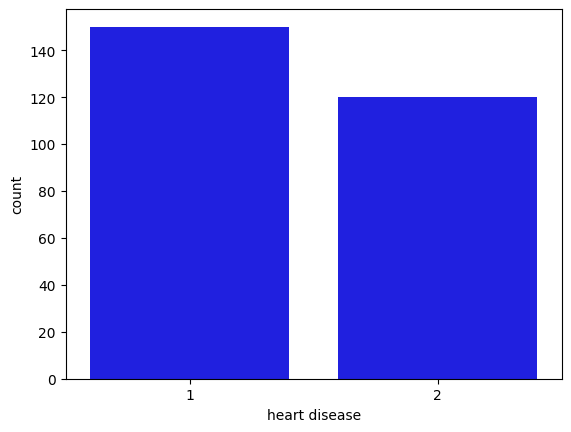

In [29]:
sns.countplot(x='heart disease',data=data,color='blue',orient="v")

In [18]:
#distribution de la variable cible 
data['heart disease'].value_counts()

heart disease
1    150
2    120
Name: count, dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'resting blood pressure'}>],
       [<Axes: title={'center': 'serum cholestoral'}>,
        <Axes: title={'center': 'max heart rate'}>],
       [<Axes: title={'center': 'oldpeak'}>, <Axes: >]], dtype=object)

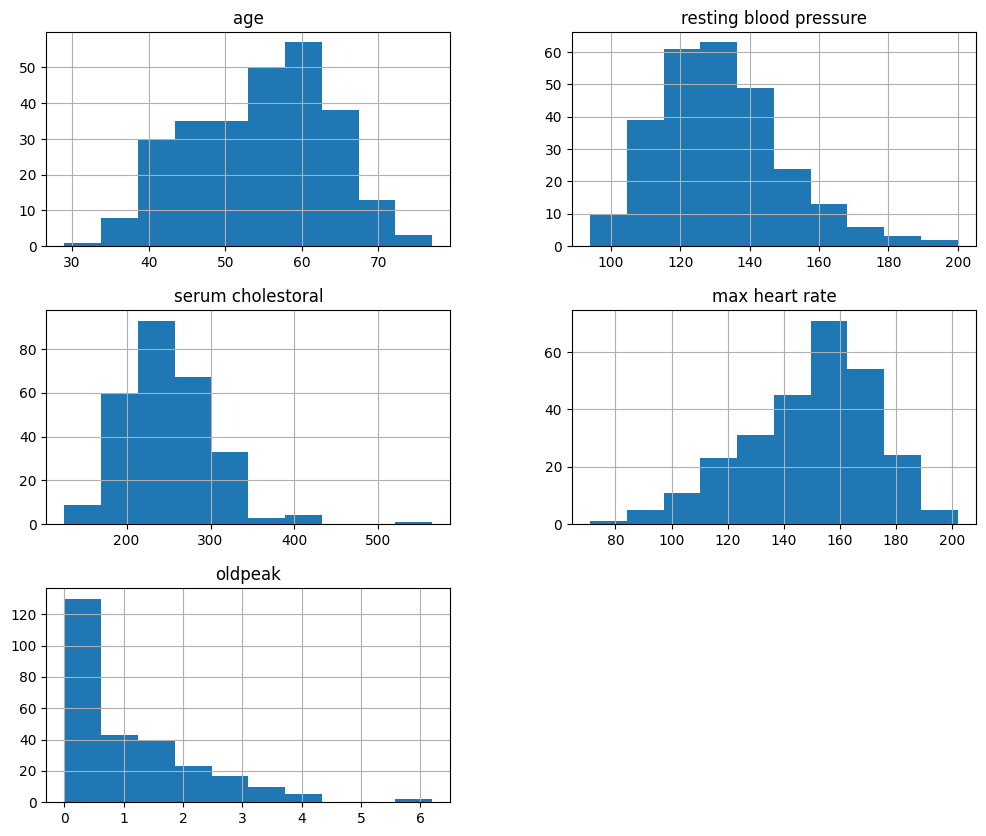

In [33]:
#histogramme
target=['age','resting blood pressure','serum cholestoral','max heart rate','oldpeak']
data[target].hist(figsize=(12,10))

<Axes: >

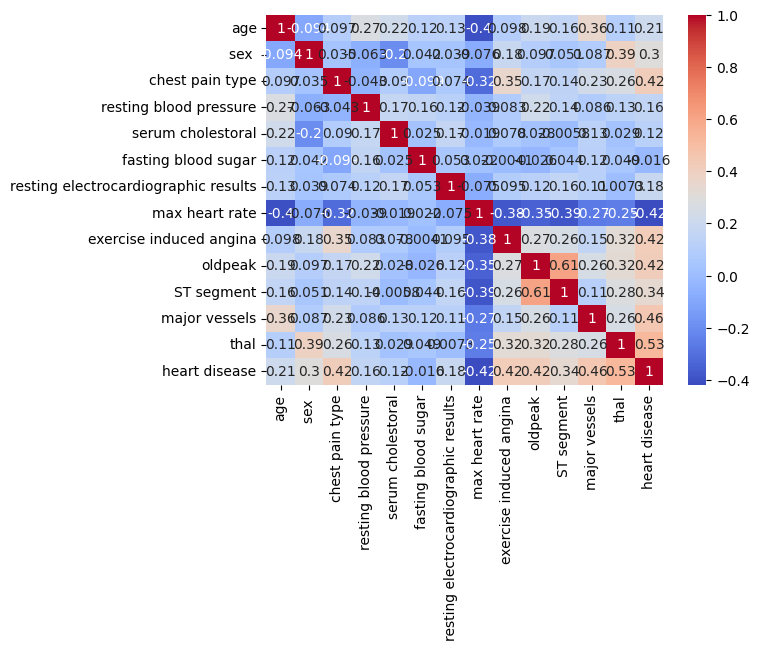

In [36]:
#correlation
import seaborn as sns

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

<Axes: >

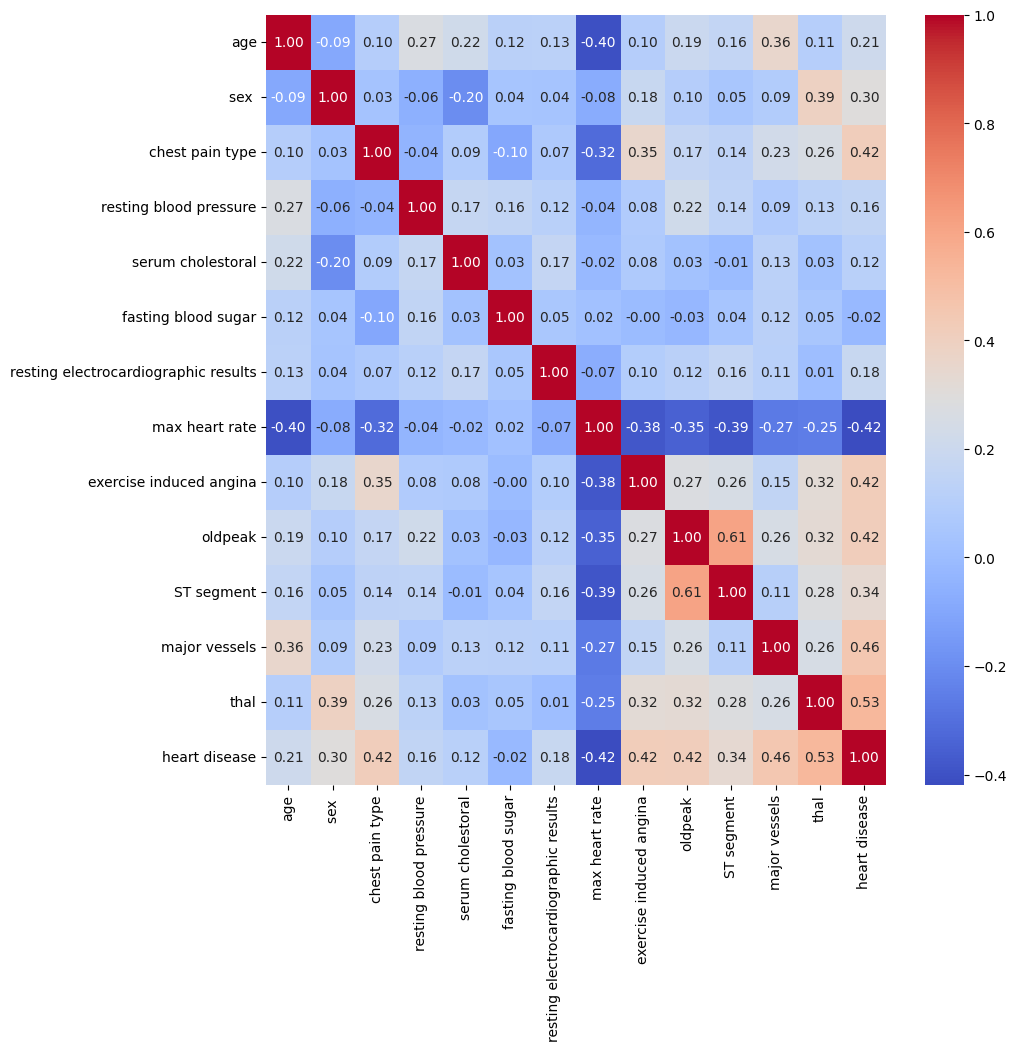

In [39]:
#correlation pearson
import matplotlib.pyplot as plt
corr=data.corr(method='pearson')
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt=".2f")

La variable thal influence le plus la cible heart disease

## Preprocessing

In [49]:
from sklearn.model_selection import train_test_split

In [62]:
X=data.drop(['heart disease'],axis=1)
Y=data['heart disease']

In [63]:
#Séparation en données d'entraînements et de test
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=43,shuffle=True)

In [66]:
#Standarisation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [67]:
Input=[('scale', StandardScaler()),
       ('model',LogisticRegression())]
pipe=Pipeline(Input)

In [68]:
pipe.fit(X_train,Y_train)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [69]:
yhat=pipe.predict(X_test)

In [71]:
from sklearn.metrics import mean_squared_error

In [73]:
mean_squared_error(Y_test,yhat)

0.16666666666666666

In [74]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
Input1=[('scale', StandardScaler()),
       ('model',RandomForestClassifier())]
pipe1=Pipeline(Input1)
pipe1.fit(X_train,Y_train)
yhat1=pipe1.predict(X_test)
mean_squared_error(Y_test,yhat1)

0.16666666666666666

In [87]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test,yhat))

              precision    recall  f1-score   support

           1       0.83      0.86      0.85        29
           2       0.83      0.80      0.82        25

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



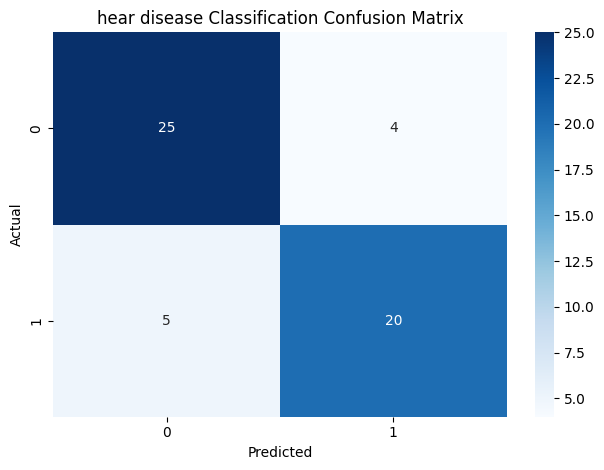

In [82]:
#matrice de confusion
conf_matrix = confusion_matrix(Y_test, yhat)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('heart disease Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

La matrice de confusion montre que le modèle identifie correctement la majorité des patients atteints de maladie cardiaque, avec un nombre limité de faux négatifs. Cela indique un bon potentiel pour la détection précoce, bien que quelques fausses alertes subsistent.

In [86]:
Le modèle a correctement identifié 25 patients non malades
Le modèle a correctement identifié 20 patients malades
Le modèle a classé 4 patients sains comme malades(moins grave en santé)
Le modèle a raté 5 patients malades(5 patients malades auraient été considérés comme sains)


[0 2 1 1]


La matrice de confusion montre que le modèle identifie correctement 83 % des cas. Il détecte 80 % des patients atteints de maladie cardiaque, ce qui est satisfaisant pour une première approche prédictive. Toutefois, 5 patients malades ne sont pas détectés, ce qui représente une limite importante dans un contexte médical où la réduction des faux négatifs est essentielle. Le modèle pourrait être amélioré afin d’augmenter le rappel et réduire le risque de non-détection des patients à risque.

# Si le recall est très bon
Le modèle privilégie la détection des patients malades, ce qui est pertinent dans un contexte médical où la réduction des faux négatifs est prioritaire.